# Classifier 1 - Plasmid vs Control training dataset

In [26]:
import BECancerResistome
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import math
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import time
from skopt import BayesSearchCV
from skopt.space import Real, Integer

In [27]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Load Data

In [28]:
#annotated_control_vs_plasmid_EG = pd.read_csv("data/6_VEP/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG.csv")
annotated_control_vs_plasmid_EG = pd.read_csv("data/8_Celular_Context/zscores-unambiguous-VEPannotated-processed-plasmid-vs-control-EG-with-gene-expression.csv")

In [29]:
annotated_control_vs_plasmid_EG.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_raw_counts,Gene_expression_voom
0,AAAAAACATCGTAGTAGCAG,CBE,RICTOR,A375,DO,-0.126512,non-hit,ENST00000357387.8,NM_152756.5,His1109Tyr,3.0,2.0,1.0,1.0,0.000,0.214,0.463040,0.0685,NaN,-0.402171,0.970933,0.045001,-4.388,5.314964,0.516773,5.75,5.75,0.917608,0.44121,0.445060,0.093490,0.179100,-1.0259,0.000785,0.345,-0.22,1.0,0.094767,226.0,0.800526,NaN,1.000,5.938,20.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.305,NaN,NaN,2813.00,5.531900
1,AAAAAACTCAACAGCAGTGA,CBE,NRAS,A375,DO,0.491844,non-hit,ENST00000369535.5,NM_002524.5,Leu171Phe,3.0,2.0,1.0,0.1,NaN,0.141,0.413488,0.1149,NaN,-0.222424,0.993713,0.120039,-5.943,3.683551,0.294249,5.86,5.86,0.865513,0.74516,1.008632,0.619943,0.190982,-0.9613,0.907693,1.385,-1.28,1.0,0.072730,819.0,0.580949,0.628916,1.000,4.055,23.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.550,NaN,NaN,6331.00,6.702081
2,AAAAAACTGGCCAGGTGAGC,CBE,PIK3CB,A375,DO,0.161287,non-hit,ENST00000674063.1,NM_006219.3,Thr930Ile,3.0,2.0,NaN,0.0,0.862,NaN,0.373381,0.7209,NaN,-0.058094,0.998396,0.879846,-10.191,4.891242,0.469329,5.63,3.78,NaN,0.73854,NaN,NaN,NaN,0.6434,0.529280,3.705,NaN,0.0,0.365695,856.0,0.310513,NaN,0.998,2.094,25.400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.0,0.319,NaN,NaN,3356.00,5.786491
3,AAAAAACTGTTTGGGACCTC,CBE,EGFR,A375,DO,-0.429684,non-hit,ENST00000275493.7,NM_005228.5,Leu480Leu,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.051,NaN,NaN,NaN,21.0,-44.0,-45.0,45.0,0.0,0.0,0.0,0.0,NaN,0.475,-0.01879,NaN,891.97,3.875409
4,AAAAAATCCAGCGTCTAAGC,CBE,MYC,A375,DO,0.122982,non-hit,ENST00000621592.8,NM_002467.6,Asp2Asn,3.0,2.0,1.0,0.0,0.199,NaN,0.453567,NaN,NaN,-0.438067,0.984375,NaN,NaN,1.792897,-0.197017,4.31,2.43,0.397160,NaN,NaN,0.733174,0.215208,-0.7405,0.036037,NaN,NaN,1.0,NaN,951.0,0.226082,0.128201,1.000,1.507,22.100,NaN,NaN,NaN,16.0,-14.0,10.0,26.0,0.0,0.0,0.0,0.0,1.0,0.128,NaN,NaN,783.00,3.687539


## Split by Cell Lines

In [126]:
annotated_control_vs_plasmid_EG_HT29 = annotated_control_vs_plasmid_EG[annotated_control_vs_plasmid_EG['Cell_Line'] == 'HT29']
annotated_control_vs_plasmid_EG_A375 = annotated_control_vs_plasmid_EG[annotated_control_vs_plasmid_EG['Cell_Line'] == 'A375']

In [127]:
print(f'HT29 shape: {annotated_control_vs_plasmid_EG_HT29.shape}')
print(f'A375 shape: {annotated_control_vs_plasmid_EG_A375.shape}')

HT29 shape: (14043, 60)
A375 shape: (14043, 60)


# Encode Labels

In [30]:
le = LabelEncoder()
annotated_control_vs_plasmid_EG['Hit_class_encoded'] = le.fit_transform(annotated_control_vs_plasmid_EG['Hit_class'])

In [128]:
# For each cell line
annotated_control_vs_plasmid_EG_HT29['Hit_class_encoded'] = le.transform(annotated_control_vs_plasmid_EG_HT29['Hit_class'])
annotated_control_vs_plasmid_EG_A375['Hit_class_encoded'] = le.transform(annotated_control_vs_plasmid_EG_A375['Hit_class'])

/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_44325/1980557596.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotated_control_vs_plasmid_EG_HT29['Hit_class_encoded'] = le.transform(annotated_control_vs_plasmid_EG_HT29['Hit_class'])
/var/folders/ry/v0cp3ptj55qfs_pd6_cghmzm0000gn/T/ipykernel_44325/1980557596.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annotated_control_vs_plasmid_EG_A375['Hit_class_encoded'] = le.transform(annotated_control_vs_plasmid_EG_A375['Hit_class'])


In [31]:
# Check encoding mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Label mapping:", label_mapping)

Label mapping: {'negative': np.int64(0), 'non-hit': np.int64(1), 'positive': np.int64(2)}


# Handle Class Imbalance

In [32]:
#combined dataset
class_counts = annotated_control_vs_plasmid_EG['Hit_class_encoded'].value_counts()
class_proportions = annotated_control_vs_plasmid_EG['Hit_class_encoded'].value_counts(normalize=True)

print("Class counts:\n", class_counts)
print("\nClass percentage:\n", (class_proportions*100).round(2))

Class counts:
 Hit_class_encoded
1    27065
0      810
2      211
Name: count, dtype: int64

Class percentage:
 Hit_class_encoded
1    96.36
0     2.88
2     0.75
Name: proportion, dtype: float64


In [131]:
#HT29
class_counts_HT29 = annotated_control_vs_plasmid_EG_HT29['Hit_class_encoded'].value_counts()
class_proportions_HT29 = annotated_control_vs_plasmid_EG_HT29['Hit_class_encoded'].value_counts(normalize=True)

print("Class counts HT29:\n", class_counts_HT29)
print("\nClass percentage HT29:\n", (class_proportions_HT29*100).round(2))

Class counts HT29:
 Hit_class_encoded
1    13430
0      450
2      163
Name: count, dtype: int64

Class percentage HT29:
 Hit_class_encoded
1    95.63
0     3.20
2     1.16
Name: proportion, dtype: float64


In [132]:
#A375
class_counts_A375 = annotated_control_vs_plasmid_EG_A375['Hit_class_encoded'].value_counts()
class_proportions_A375 = annotated_control_vs_plasmid_EG_A375['Hit_class_encoded'].value_counts(normalize=True)
print("Class counts A375:\n", class_counts_A375)
print("\nClass percentage A375:\n", (class_proportions_A375*100).round(2))

Class counts A375:
 Hit_class_encoded
1    13635
0      360
2       48
Name: count, dtype: int64

Class percentage A375:
 Hit_class_encoded
1    97.09
0     2.56
2     0.34
Name: proportion, dtype: float64


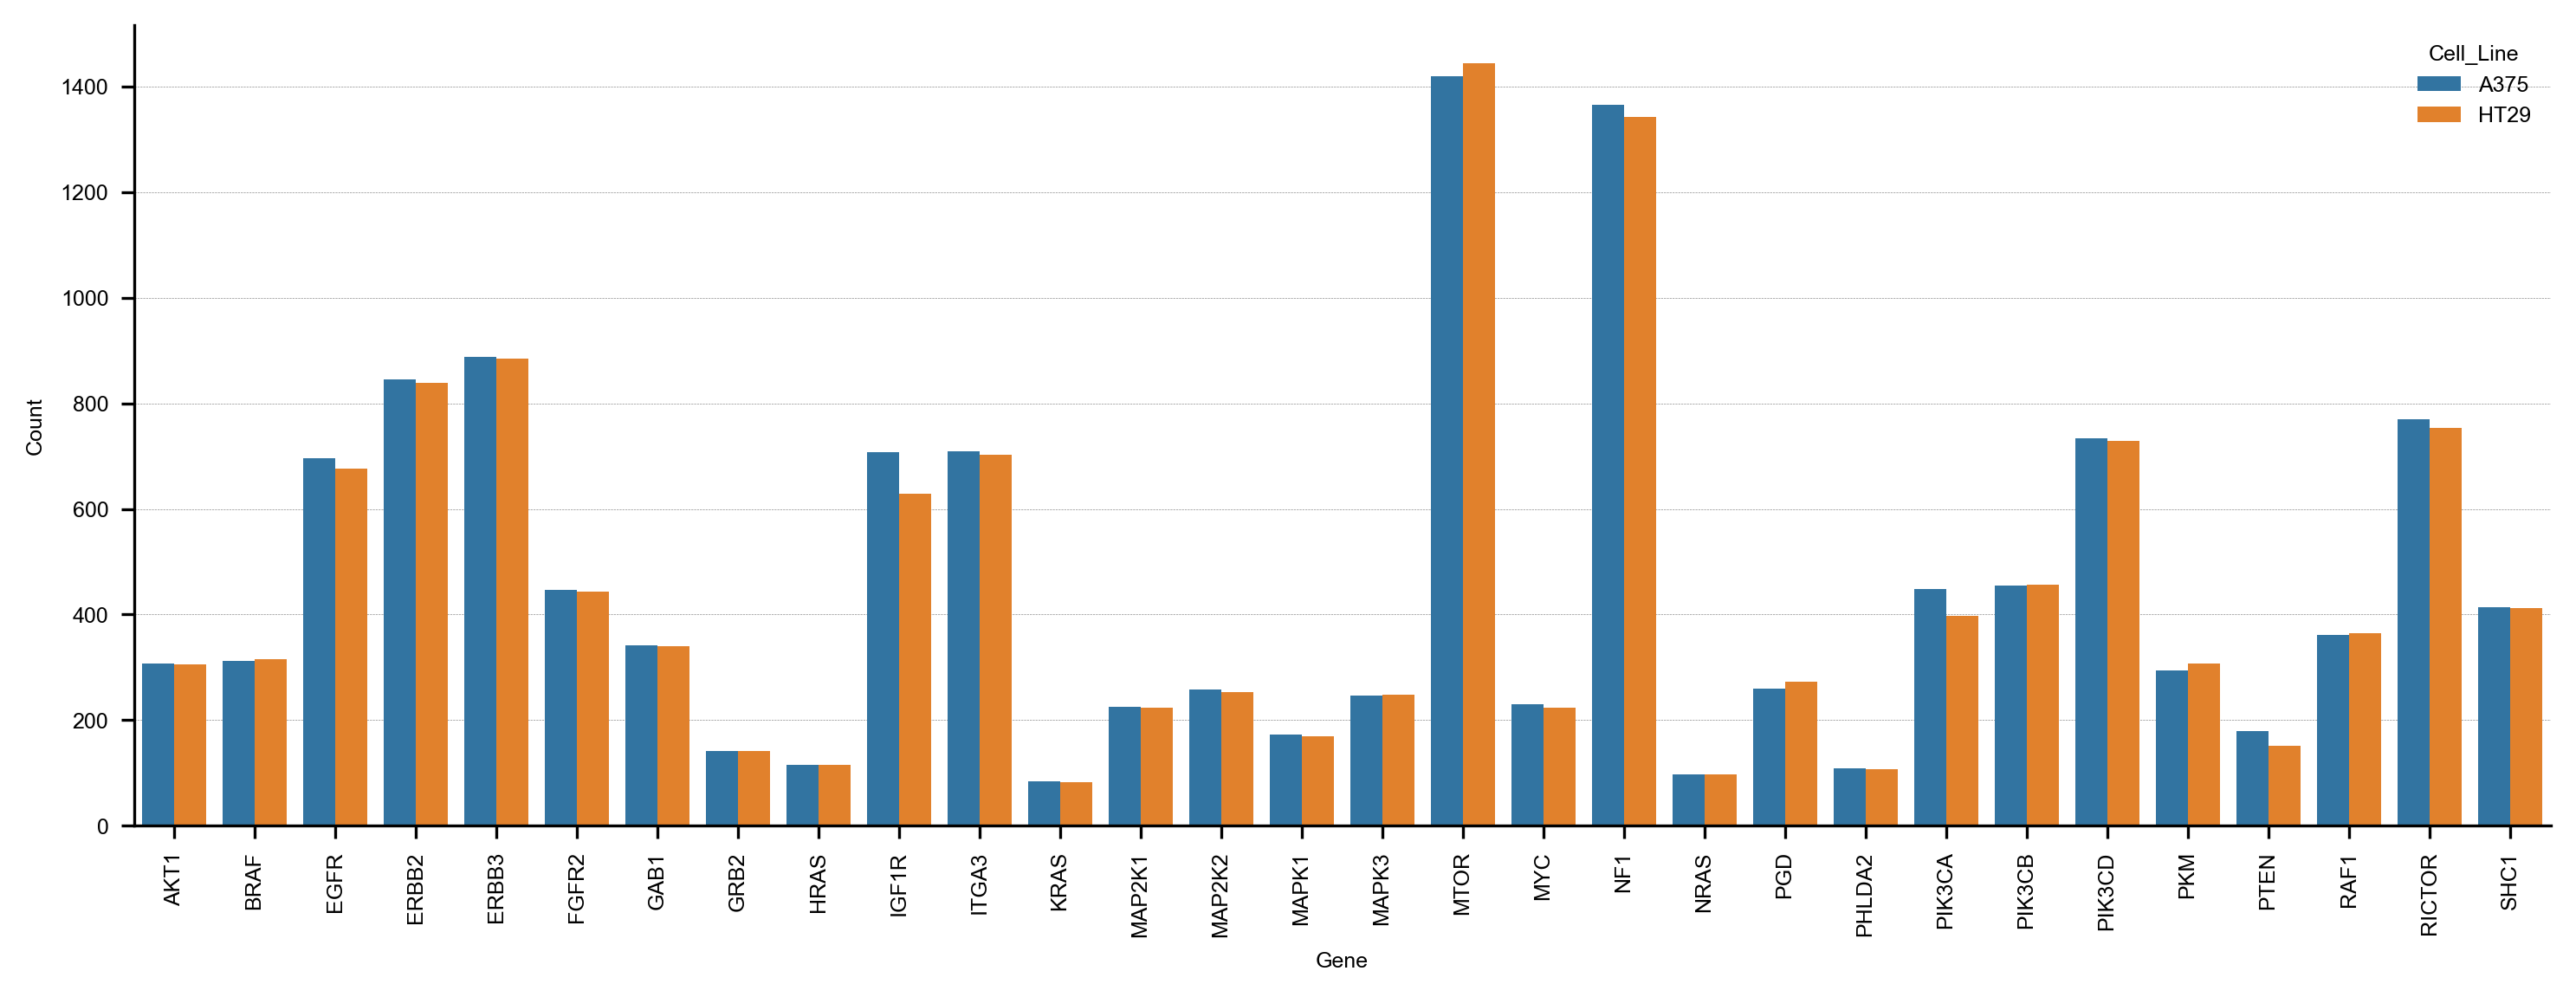

In [40]:
counts_before_DS = (
    annotated_control_vs_plasmid_EG
    .groupby(["Cell_Line", "Gene", "Hit_class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_before_DS = counts_before_DS[counts_before_DS["Hit_class"] == "non-hit"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_before_DS,
    x="Gene", y="Count", hue='Cell_Line', errorbar=None
)

plt.xticks(rotation=90)
plt.show()

### Stratified Downsampling

In [41]:
df = annotated_control_vs_plasmid_EG.copy()

#Split dataset by class
df_negative = df[df['Hit_class'] == 'negative']
df_non_hit = df[df['Hit_class'] == 'non-hit']
df_positive = df[df['Hit_class'] == 'positive']

#Target number of non-hit samples to match negative samples
target_non_hit_count = len(df_negative)

# Compute distribution of non-hits across Cell_Line × Gene
non_hit_distribution = (
    df_non_hit
    .groupby(['Cell_Line', 'Gene'])
    .size()
    .reset_index(name='Count')
)

# Calculate proportions
non_hit_distribution['Proportion'] = non_hit_distribution['Count'] / non_hit_distribution['Count'].sum()

# Determine number of samples to select from each Cell_Line × Gene
non_hit_distribution['Target'] = np.floor(non_hit_distribution['Proportion'] * target_non_hit_count).astype(int)

# Adjust target to ensure total matches target_non_hit_count - distribute the remaining samples to the groups with the largest fractional remainders
#difference = target_non_hit_count - non_hit_distribution['Target'].sum()
difference = int(round(target_non_hit_count - non_hit_distribution['Target'].sum()))

if difference > 0:
    fractional_parts = non_hit_distribution['Proportion'] * target_non_hit_count - non_hit_distribution['Target']
    top_idx = fractional_parts.nlargest(difference).index
    non_hit_distribution.loc[top_idx, 'Target'] += 1

#Perform stratified downsampling
downsampled_non_hits = []
for _, row in non_hit_distribution.iterrows():
    cell_line = row['Cell_Line']
    gene = row['Gene']
    target = row['Target']
    
    subset = df_non_hit[(df_non_hit['Cell_Line'] == cell_line) & (df_non_hit['Gene'] == gene)]

    if target > 0:
        n_sampled = min(target, len(subset)) # in case very small group
        downsampled_non_hits.append(subset.sample(n=n_sampled, random_state=1))
    
df_non_hit_downsampled = pd.concat(downsampled_non_hits, ignore_index=True)

# Combine downsampled non-hits with other classes
annotated_control_vs_plasmid_EG_balanced = pd.concat([df_negative, df_non_hit_downsampled, df_positive], ignore_index=True)


In [21]:
def stratified_downsampling(df, random_state=None):
    """
    Perform stratified downsampling of 'non-hit' class to match the size of the 'negative' class,
    stratified by (Cell_Line × Gene).
    
    Parameters
    ----------
    df : pd.DataFrame
        Original dataset with 'Hit_class', 'Cell_Line', and 'Gene'.
    random_state : int, optional
        Random seed for reproducibility of subsampling.

    Returns
    -------
    df_balanced : pd.DataFrame
        Balanced dataset containing all negatives, all positives, and downsampled non-hits.
    """
    #Split dataset by class
    df_negative = df[df['Hit_class'] == 'negative']
    df_non_hit = df[df['Hit_class'] == 'non-hit']
    df_positive = df[df['Hit_class'] == 'positive']

    #Target number of non-hit samples to match negative samples
    target_non_hit_count = len(df_negative)

    # Compute distribution of non-hits across Cell_Line × Gene
    non_hit_distribution = (
        df_non_hit
        .groupby(['Cell_Line', 'Gene'])
        .size()
        .reset_index(name='Count')
    )

    # Calculate proportions
    non_hit_distribution['Proportion'] = non_hit_distribution['Count'] / non_hit_distribution['Count'].sum()

    # Determine number of samples to select from each Cell_Line × Gene
    non_hit_distribution['Target'] = np.floor(non_hit_distribution['Proportion'] * target_non_hit_count).astype(int)

    # Adjust target to ensure total matches target_non_hit_count - distribute the remaining samples to the groups with the largest fractional remainders
    difference = target_non_hit_count - non_hit_distribution['Target'].sum()

    if difference > 0:
        fractional_parts = non_hit_distribution['Proportion'] * target_non_hit_count - non_hit_distribution['Target']
        top_idx = fractional_parts.nlargest(difference).index
        non_hit_distribution.loc[top_idx, 'Target'] += 1

    #Perform stratified downsampling
    downsampled_non_hits = []
    for _, row in non_hit_distribution.iterrows():
        cell_line = row['Cell_Line']
        gene = row['Gene']
        target = row['Target']
        
        subset = df_non_hit[(df_non_hit['Cell_Line'] == cell_line) & (df_non_hit['Gene'] == gene)]

        if target > 0:
            n_sampled = min(target, len(subset)) # in case very small group
            downsampled_non_hits.append(subset.sample(n=n_sampled, random_state=random_state))
        
    df_non_hit_downsampled = pd.concat(downsampled_non_hits, ignore_index=True)

    # Combine downsampled non-hits with other classes
    df_balanced = pd.concat([df_negative, df_non_hit_downsampled, df_positive], ignore_index=True)

    return df_balanced

        


In [42]:
print("Final class counts:")
print(annotated_control_vs_plasmid_EG_balanced["Hit_class"].value_counts())

Final class counts:
Hit_class
negative    810
non-hit     810
positive    211
Name: count, dtype: int64


In [36]:
annotated_control_vs_plasmid_EG_balanced.head()

,Guide,Editor,Gene,Cell_Line,Drug,zscore,Hit_class,Target Transcript ID,RefSeq match transcript (MANE Select),Amino Acid Edits,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_raw_counts,Gene_expression_voom,Hit_class_encoded
0,AAAATCTGTAAGGGAAGAGA,CBE,IGF1R,A375,DO,-2.054192,negative,ENST00000650285.1,NM_000875.5,(NC),5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,5.162,8.75,13.913,-1.0,1.0,34.0,18.0,0.02,1.0,0.0,0.0,NaN,0.330,NaN,0.999986,12211.0,7.649702,0
1,AAAGCAGTCCCCAAAGTCAA,CBE,MTOR,A375,DO,-3.851780,negative,ENST00000361445.9,NM_004958.4,Cys2361Tyr,3.0,2.0,1.0,0.0,NaN,0.876,0.999938,0.9997,0.983177,0.376218,0.998253,0.901346,-14.646,16.6271,0.960830,5.51,5.51,0.963704,0.99644,3.350520,0.949545,0.947140,0.8686,0.996138,4.49,-9.76,0.0,0.992620,403.0,0.892481,0.998039,1.0,7.248,27.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,0.268,NaN,NaN,8088.0,7.055406,0
2,AAAGGCAGGGTTCATGCTAC,CBE,MTOR,A375,DO,-4.273213,negative,ENST00000361445.9,NM_004958.4,Ala724Thr,3.0,2.0,1.0,0.0,0.995,0.430,0.944457,0.9638,0.806266,0.006105,0.999447,0.782876,-7.062,11.7622,0.849728,5.70,5.70,0.909909,0.88192,1.573937,0.683547,0.892936,-0.2861,0.082219,3.48,-3.64,0.0,0.899651,291.0,0.857350,0.640744,1.0,7.478,25.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.268,NaN,NaN,8088.0,7.055406,0
3,AAAGGCATGTTTGAGGTGCT,CBE,MTOR,A375,DO,-4.732194,negative,ENST00000361445.9,NM_004958.4,Gly2046Gly,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.268,0.0,NaN,8088.0,7.055406,0
4,AAATCTGTAAGGGAAGAGAG,CBE,IGF1R,A375,DO,-1.109615,negative,ENST00000650285.1,NM_000875.5,(NC),5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,5.162,8.75,13.913,-1.0,1.0,34.0,18.0,0.02,1.0,0.0,0.0,NaN,0.330,NaN,0.999986,12211.0,7.649702,0


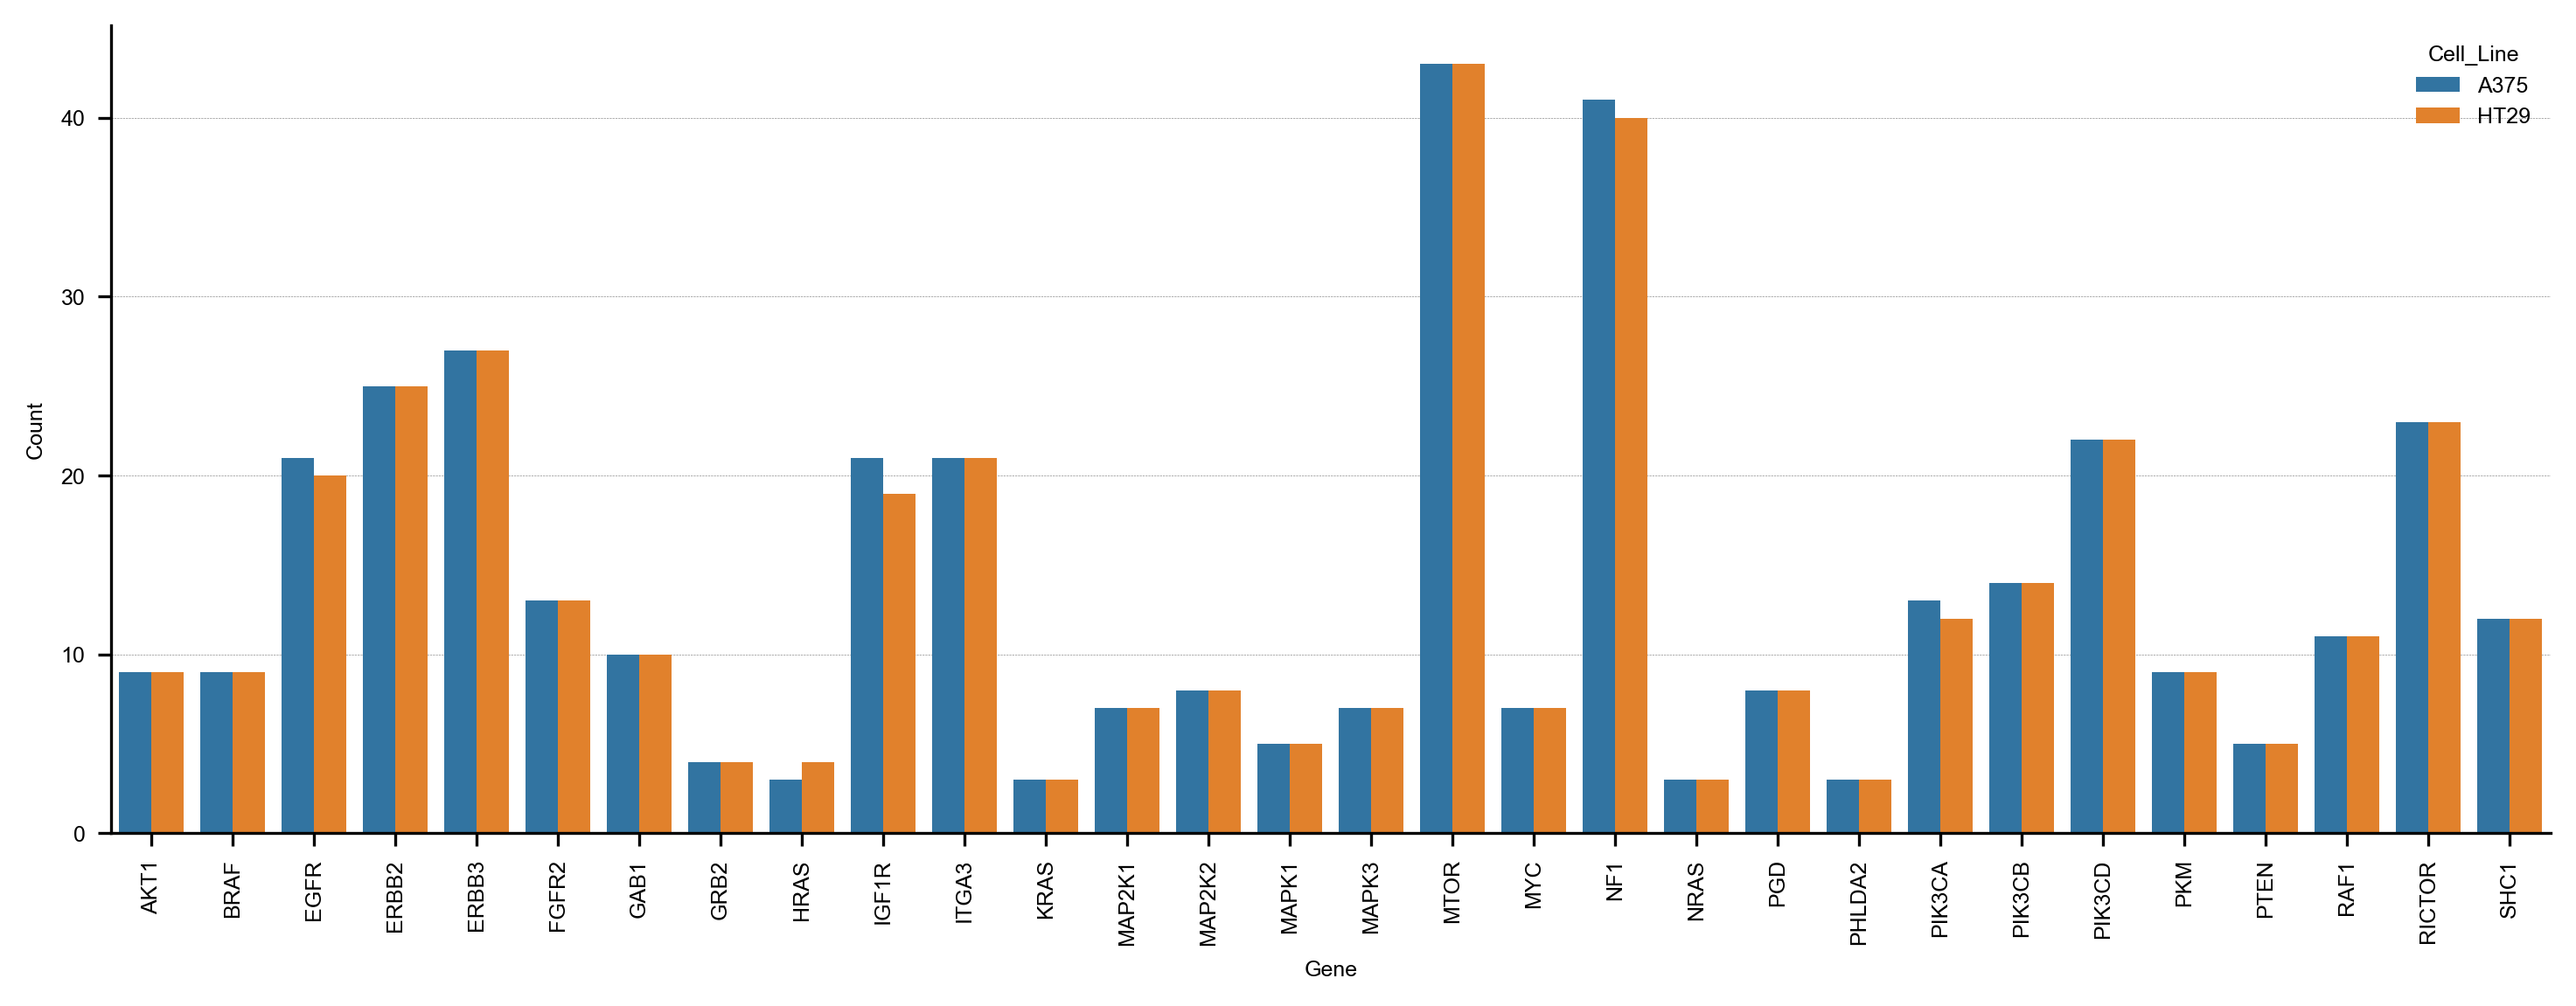

In [43]:
#Check distribution of non-hits after downsampling

counts_after_DS = (
    annotated_control_vs_plasmid_EG_balanced
    .groupby(["Cell_Line", "Gene", "Hit_class"])
    .size()
    .reset_index(name="Count")
)

counts_non_hits_after_DS = counts_after_DS[counts_after_DS["Hit_class"] == "non-hit"]

plt.figure(figsize=(12,4))
sns.barplot(
    data=counts_non_hits_after_DS,
    x="Gene", y="Count", hue="Cell_Line", errorbar=None
)

plt.xticks(rotation=90)
plt.show()

In [141]:
#Create a df to compare the proportions of each class before and after downsampling
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_control_vs_plasmid_EG_HT29['Hit_class'].value_counts(normalize=True).sort_index() * 100,
    'After_Downsampling': annotated_control_vs_plasmid_EG_HT29_balanced['Hit_class'].value_counts(normalize=True).sort_index() * 100
}).reset_index().rename(columns={'index': 'Hit_class'})

In [188]:
#Create a df to compare the proportins of each class before and after downsampling
comparison_df = pd.DataFrame({
    'Before_Downsampling': annotated_control_vs_plasmid_EG_HT29['Hit_class'].value_counts().sort_index(),
    'After_Downsampling': annotated_control_vs_plasmid_EG_HT29_balanced['Hit_class'].value_counts().sort_index()
}).reset_index().rename(columns={'index': 'Hit_class'})

In [189]:
comparison_df

,Hit_class,Before_Downsampling,After_Downsampling
0,negative,450,450
1,non-hit,13430,450
2,positive,163,163


In [28]:
#Create a df to compare the proportions of each gene x cell line group in the non-hits class before and after downsampling
non_hit_comparison_df = pd.DataFrame({
    'Before_Downsampling': counts_non_hits_before_DS.set_index(['Cell_Line', 'Gene'])['Count'],
    'After_Downsampling': counts_non_hits_after_DS.set_index(['Cell_Line', 'Gene'])['Count']
}).reset_index()

In [164]:
non_hit_comparison_df = pd.DataFrame({
    'Before_Downsampling': counts_non_hits_before_DS.set_index(['Gene'])['Count'],
    'After_Downsampling': counts_non_hits_after_DS.set_index(['Gene'])['Count']
}).reset_index()

In [166]:
non_hit_comparison_df

,Gene,Before_Downsampling,After_Downsampling
0,AKT1,308,8
1,BRAF,313,8
2,EGFR,696,18
3,ERBB2,845,22
4,ERBB3,888,23
5,FGFR2,446,12
6,GAB1,341,9
7,GRB2,142,4
8,HRAS,115,3
9,IGF1R,707,19


In [44]:
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Cell_Line", "Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Cell_Line", "Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on=["Cell_Line", "Gene"], how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of per-group proportions (before vs after downsampling):", round(corr, 4))
print("\nProportion comparison (first 20 rows):")
print(prop_compare.head(20))

Correlation of per-group proportions (before vs after downsampling): 0.9995

Proportion comparison (first 20 rows):
   Cell_Line    Gene  Proportion_before_DS  Proportion_after_DS
0       A375    AKT1                0.0114               0.0111
1       A375    BRAF                0.0116               0.0111
2       A375    EGFR                0.0257               0.0259
3       A375   ERBB2                0.0312               0.0309
4       A375   ERBB3                0.0328               0.0333
5       A375   FGFR2                0.0165               0.0160
6       A375    GAB1                0.0126               0.0123
7       A375    GRB2                0.0052               0.0049
8       A375    HRAS                0.0042               0.0037
9       A375   IGF1R                0.0261               0.0259
10      A375   ITGA3                0.0262               0.0259
11      A375    KRAS                0.0031               0.0037
12      A375  MAP2K1                0.0083          

In [190]:
# for the specific cell lines
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on="Gene", how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of gene proportions (before vs after downsampling) for HT29:", round(corr, 4))
print("\nProportion comparison (first 20 rows):")
print(prop_compare.head(20))

Correlation of gene proportions (before vs after downsampling) for HT29: 0.9996

Proportion comparison (first 20 rows):
      Gene  Proportion_before_DS  Proportion_after_DS
0     AKT1                0.0228               0.0222
1     BRAF                0.0235               0.0244
2     EGFR                0.0504               0.0511
3    ERBB2                0.0624               0.0622
4    ERBB3                0.0658               0.0667
5    FGFR2                0.0331               0.0333
6     GAB1                0.0253               0.0244
7     GRB2                0.0105               0.0111
8     HRAS                0.0086               0.0089
9    IGF1R                0.0468               0.0467
10   ITGA3                0.0523               0.0533
11    KRAS                0.0062               0.0067
12  MAP2K1                0.0166               0.0156
13  MAP2K2                0.0189               0.0200
14   MAPK1                0.0126               0.0133
15   MAPK3      

In [193]:
# for the specific cell lines
# Compute proportions within each group (Cell_Line × Gene)
prop_before = counts_non_hits_before_DS.copy()
prop_before["Proportion_before_DS"] = round(prop_before["Count"] / prop_before["Count"].sum(),4)
prop_before = prop_before[["Gene", "Proportion_before_DS"]]

prop_after = counts_non_hits_after_DS.copy()
prop_after["Proportion_after_DS"] = round(prop_after["Count"] / prop_after["Count"].sum(), 4)
prop_after = prop_after[["Gene", "Proportion_after_DS"]]


prop_compare = pd.merge(prop_before, prop_after,
                        on="Gene", how="inner")

# Correlation of proportions
corr = prop_compare["Proportion_before_DS"].corr(prop_compare["Proportion_after_DS"])

print("Correlation of gene proportions (before vs after downsampling) for A375:", round(corr, 4))
print("\nProportion comparison (first 20 rows):")
print(prop_compare.head(20))

Correlation of gene proportions (before vs after downsampling) for A375: 0.9996

Proportion comparison (first 20 rows):
      Gene  Proportion_before_DS  Proportion_after_DS
0     AKT1                0.0226               0.0222
1     BRAF                0.0230               0.0222
2     EGFR                0.0510               0.0500
3    ERBB2                0.0620               0.0611
4    ERBB3                0.0651               0.0639
5    FGFR2                0.0327               0.0333
6     GAB1                0.0250               0.0250
7     GRB2                0.0104               0.0111
8     HRAS                0.0084               0.0083
9    IGF1R                0.0519               0.0528
10   ITGA3                0.0520               0.0528
11    KRAS                0.0062               0.0056
12  MAP2K1                0.0165               0.0167
13  MAP2K2                0.0189               0.0194
14   MAPK1                0.0127               0.0139
15   MAPK3      

# Modeling

## Split into Features (X) and labels (y)

In [46]:
#Define meta data columns to drop
meta_cols=[
    'Target Transcript ID', 'RefSeq match transcript (MANE Select)', 'Guide', 'Editor', 'Gene', 'Cell_Line','Drug', 'Amino Acid Edits', 
    'Hit_class', 'zscore', "Gene_expression_voom", 
]

#Split into features and labels
X = annotated_control_vs_plasmid_EG_balanced.drop(columns=meta_cols + ["Hit_class_encoded"])
y = annotated_control_vs_plasmid_EG_balanced["Hit_class_encoded"]

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (1831, 50)
Label vector shape: (1831,)


In [171]:
#for specific cell lines
X_ht29 = annotated_control_vs_plasmid_EG_HT29_balanced.drop(columns=meta_cols + ["Hit_class_encoded"])
y_ht29 = annotated_control_vs_plasmid_EG_HT29_balanced["Hit_class_encoded"]

X_a375 = annotated_control_vs_plasmid_EG_A375_balanced.drop(columns=meta_cols + ["Hit_class_encoded"])
y_a375 = annotated_control_vs_plasmid_EG_A375_balanced["Hit_class_encoded"]

print("Feature matrix shape HT29:", X_ht29.shape)
print("Label vector shape HT29:", y_ht29.shape)
print("Feature matrix shape A375:", X_a375.shape)
print("Label vector shape A375:", y_a375.shape)

Feature matrix shape HT29: (1063, 49)
Label vector shape HT29: (1063,)
Feature matrix shape A375: (768, 49)
Label vector shape A375: (768,)


In [19]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Hit_class_encoded, dtype: int64

In [48]:
X.head()

,Mutation_Category_enc,IMPACT_enc,TSL,SIFT_pathogenicity,PolyPhen_pathogenicity,REVEL,ClinPred,am_pathogenicity,EVE_SCORE,BayesDel_noAF_score,DANN_score,DEOGEN2_score,ESM1b_score,Eigen-PC-phred_coding,Eigen-PC-raw_coding,GERP++_NR,GERP++_RS,LIST-S2_score,MPC_rankscore,MPC_score,MVP_score,MetaRNN_score,MetaSVM_score,MutFormer_score,MutationAssessor_score,PROVEAN_score,PrimateAI_pred_enc,VARITY_R_LOO_score,bStatistic,fathmm-XF_coding_score,gMVP_score,phastCons100way_vertebrate,phyloP100way_vertebrate,CADD_PHRED,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,BLOSUM62,LOEUF,mutfunc_exp,ada_score,Gene_expression_raw_counts
0,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,5.162,8.75,13.913,-1.0,1.0,34.0,18.0,0.02,1.0,0.0,0.0,NaN,0.330,NaN,0.999986,12211.0
1,3.0,2.0,1.0,0.0,NaN,0.876,0.999938,0.9997,0.983177,0.376218,0.998253,0.901346,-14.646,16.6271,0.960830,5.51,5.51,0.963704,0.99644,3.350520,0.949545,0.947140,0.8686,0.996138,4.49,-9.76,0.0,0.992620,403.0,0.892481,0.998039,1.0,7.248,27.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0,0.268,NaN,NaN,8088.0
2,3.0,2.0,1.0,0.0,0.995,0.430,0.944457,0.9638,0.806266,0.006105,0.999447,0.782876,-7.062,11.7622,0.849728,5.70,5.70,0.909909,0.88192,1.573937,0.683547,0.892936,-0.2861,0.082219,3.48,-3.64,0.0,0.899651,291.0,0.857350,0.640744,1.0,7.478,25.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.268,NaN,NaN,8088.0
3,2.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.268,0.0,NaN,8088.0
4,5.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.0,5.162,8.75,13.913,-1.0,1.0,34.0,18.0,0.02,1.0,0.0,0.0,NaN,0.330,NaN,0.999986,12211.0


In [ ]:
#Check missing values again
X_info = pd.DataFrame({
    'dtype': X.dtypes,
    'non-null count': X.notna().sum(),
    'missing (%)': X.isna().mean() * 100,
    'n_unique': X.nunique(),
    'example': X.apply(lambda col: col.dropna().unique()[:3])
}).sort_values('missing (%)', ascending=True)

print(f'{len(X)} rows and {len(X.columns)} columns')
X_info

## Baseline

In [15]:
#first with no hyperparameter tuning
xgb_classifier = XGBClassifier(random_state=1)

#Model with optimized hyperparameters for A375
xgb_classifier_optimized_a375 = XGBClassifier(
    subsample=0.85,
    reg_lambda=0.7,
    reg_alpha=0,
    n_estimators=300,
    min_child_weight=3,
    max_depth=6,
    learning_rate=0.1,
    colsample_bytree=1,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Model with optimized hyperparameters for Ht29
xgb_classifier_optimized_ht29 = XGBClassifier(
    subsample=1.0,
    reg_lambda=1.3,
    reg_alpha=1,
    n_estimators=1000,
    min_child_weight=1,
    max_depth=9,
    learning_rate=0.01,
    colsample_bytree=1,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Model with optimized hyperparameters 
xgb_classifier_optimized = XGBClassifier(
    subsample=0.85,
    reg_lambda=1.3,
    reg_alpha=1,
    n_estimators=300,
    min_child_weight=3,
    max_depth=9,
    learning_rate=0.2,
    colsample_bytree=1.0,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Model with optimized hyperparameters 
xgb_classifier_optimized_bayesian = XGBClassifier(
    subsample=0.9167449779875692,
    reg_lambda=2.0,
    reg_alpha=0.08430984461758138,
    n_estimators=2000,
    min_child_weight=2,
    max_depth=9,
    learning_rate=0.016988937755638818,
    colsample_bytree=0.8354720212782338,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

#Stratified 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

#colect predictions and true labels for each fold + metrics
fold_classif_reports = []
roc_auc_scores_weighted = []
roc_auc_scores_macro = []
pr_auc_scores_weighted = []
pr_auc_scores_macro = []
all_y_true = []
all_y_pred = []


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_classifier_optimized.fit(X_train, y_train)
    y_pred = xgb_classifier_optimized.predict(X_val)
    probs = xgb_classifier_optimized.predict_proba(X_val) 

    #ROC AUC
    roc_auc_weighted = roc_auc_score(y_val, probs, multi_class="ovr", average='weighted')
    roc_auc_macro = roc_auc_score(y_val, probs, multi_class="ovr", average='macro')
    roc_auc_scores_weighted.append(roc_auc_weighted)
    roc_auc_scores_macro.append(roc_auc_macro)

    #PR AUC
    pr_auc_weighted = average_precision_score(y_val, probs, average='weighted')
    pr_auc_macro = average_precision_score(y_val, probs, average='macro')

    pr_auc_scores_weighted.append(pr_auc_weighted)
    pr_auc_scores_macro.append(pr_auc_macro)


    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)

    report = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
    fold_classif_reports.append(report)

    print(f"\n=== Fold {fold+1} ===")
    print(classification_report(y_val, y_pred, target_names=le.classes_, digits=3))
    print(f"ROC AUC (weighted): {roc_auc_weighted:.3f}")
    print(f"PR AUC (weighted): {pr_auc_weighted:.3f}")


=== Fold 1 ===
              precision    recall  f1-score   support

    negative      0.814     0.889     0.850       162
     non-hit      0.788     0.802     0.795       162
    positive      0.680     0.395     0.500        43

    accuracy                          0.793       367
   macro avg      0.760     0.696     0.715       367
weighted avg      0.787     0.793     0.785       367

ROC AUC (weighted): 0.903
PR AUC (weighted): 0.841

=== Fold 2 ===
              precision    recall  f1-score   support

    negative      0.858     0.858     0.858       162
     non-hit      0.763     0.833     0.796       162
    positive      0.630     0.405     0.493        42

    accuracy                          0.795       366
   macro avg      0.750     0.699     0.716       366
weighted avg      0.790     0.795     0.789       366

ROC AUC (weighted): 0.889
PR AUC (weighted): 0.812

=== Fold 3 ===
              precision    recall  f1-score   support

    negative      0.827     0.883

In [16]:
# === Average metrics ===
avg_report = {}
avg_report["accuracy"] = np.mean([r["accuracy"] for r in fold_classif_reports])
avg_report["macro avg"] = {
    metric: np.mean([r["macro avg"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["weighted avg"] = {
    metric: np.mean([r["weighted avg"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}

avg_report["positive"] = {
    metric: np.mean([r["positive"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["negative"] = {
    metric: np.mean([r["negative"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}
avg_report["non-hit"] = {
    metric: np.mean([r["non-hit"][metric] for r in fold_classif_reports])
    for metric in ["precision", "recall", "f1-score"]
}

avg_roc_auc_weighthed = np.mean(roc_auc_scores_weighted)
avg_roc_auc_macro = np.mean(roc_auc_scores_macro)

avg_pr_auc_weighthed = np.mean(pr_auc_scores_weighted)
avg_pr_auc_macro = np.mean(pr_auc_scores_macro)

def round_dict(d, ndigits=3):
    return {k: round(float(v), ndigits) for k, v in d.items()}

print("\n=== Average CV Results ===")
print("Accuracy:", round(float(avg_report["accuracy"]), 3))
print("ROC AUC (weighted):", round(float(avg_roc_auc_weighthed), 3))
print("ROC AUC (macro):", round(float(avg_roc_auc_macro), 3))
print("PR AUC (weighted):", round(float(avg_pr_auc_weighthed), 3))
print("PR AUC (macro):", round(float(avg_pr_auc_macro), 3))
print("\nClass-wise metrics:")
print("Positive:", round_dict(avg_report["positive"]))
print("Negative:", round_dict(avg_report["negative"]))
print("Non-hit:", round_dict(avg_report["non-hit"]))
print("\nMacro Avg:", round_dict(avg_report["macro avg"]))
print("Weighted Avg:", round_dict(avg_report["weighted avg"]))




=== Average CV Results ===
Accuracy: 0.799
ROC AUC (weighted): 0.894
ROC AUC (macro): 0.873
PR AUC (weighted): 0.831
PR AUC (macro): 0.757

Class-wise metrics:
Positive: {'precision': 0.689, 'recall': 0.412, 'f1-score': 0.514}
Negative: {'precision': 0.84, 'recall': 0.873, 'f1-score': 0.856}
Non-hit: {'precision': 0.776, 'recall': 0.826, 'f1-score': 0.8}

Macro Avg: {'precision': 0.769, 'recall': 0.704, 'f1-score': 0.723}
Weighted Avg: {'precision': 0.795, 'recall': 0.799, 'f1-score': 0.792}


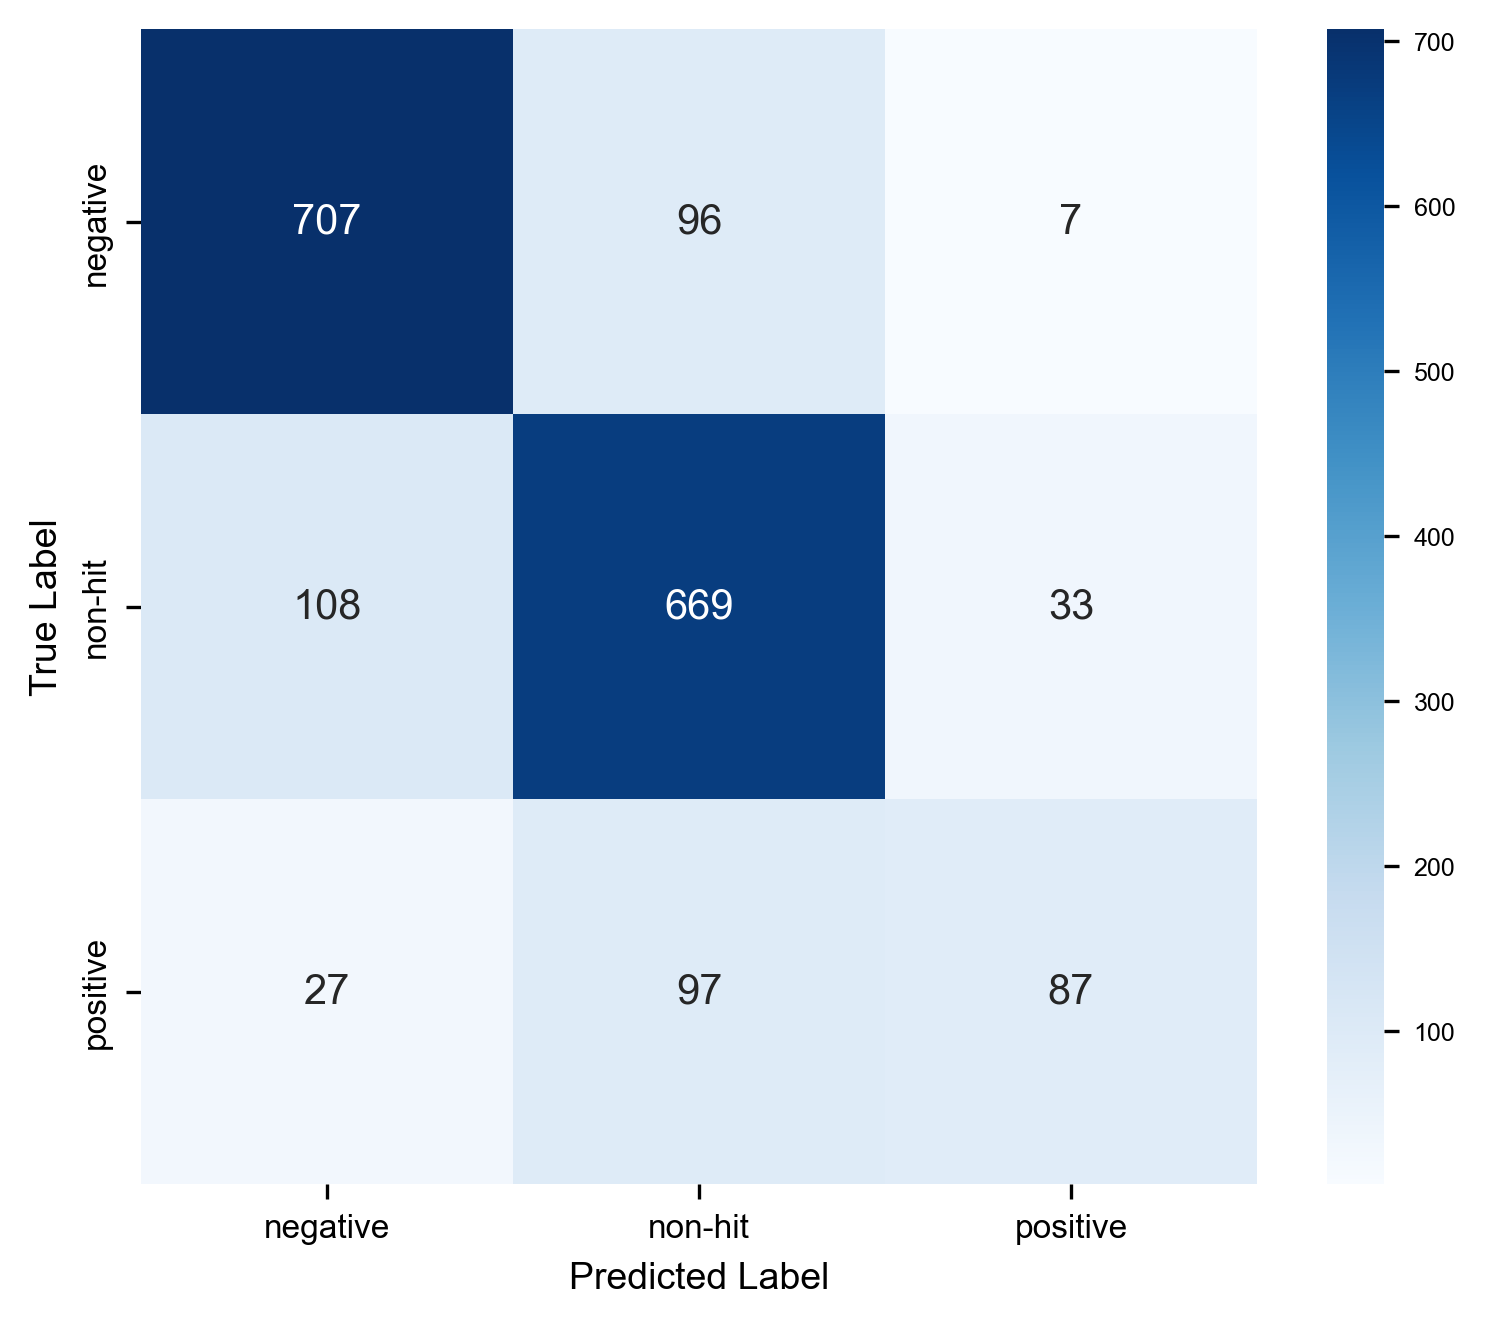

In [17]:
# Single-run confusion matrix plotting
cm = confusion_matrix(all_y_true, all_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.xlabel("Predicted Label", fontsize=9)
plt.ylabel("True Label", fontsize=9)
plt.show()

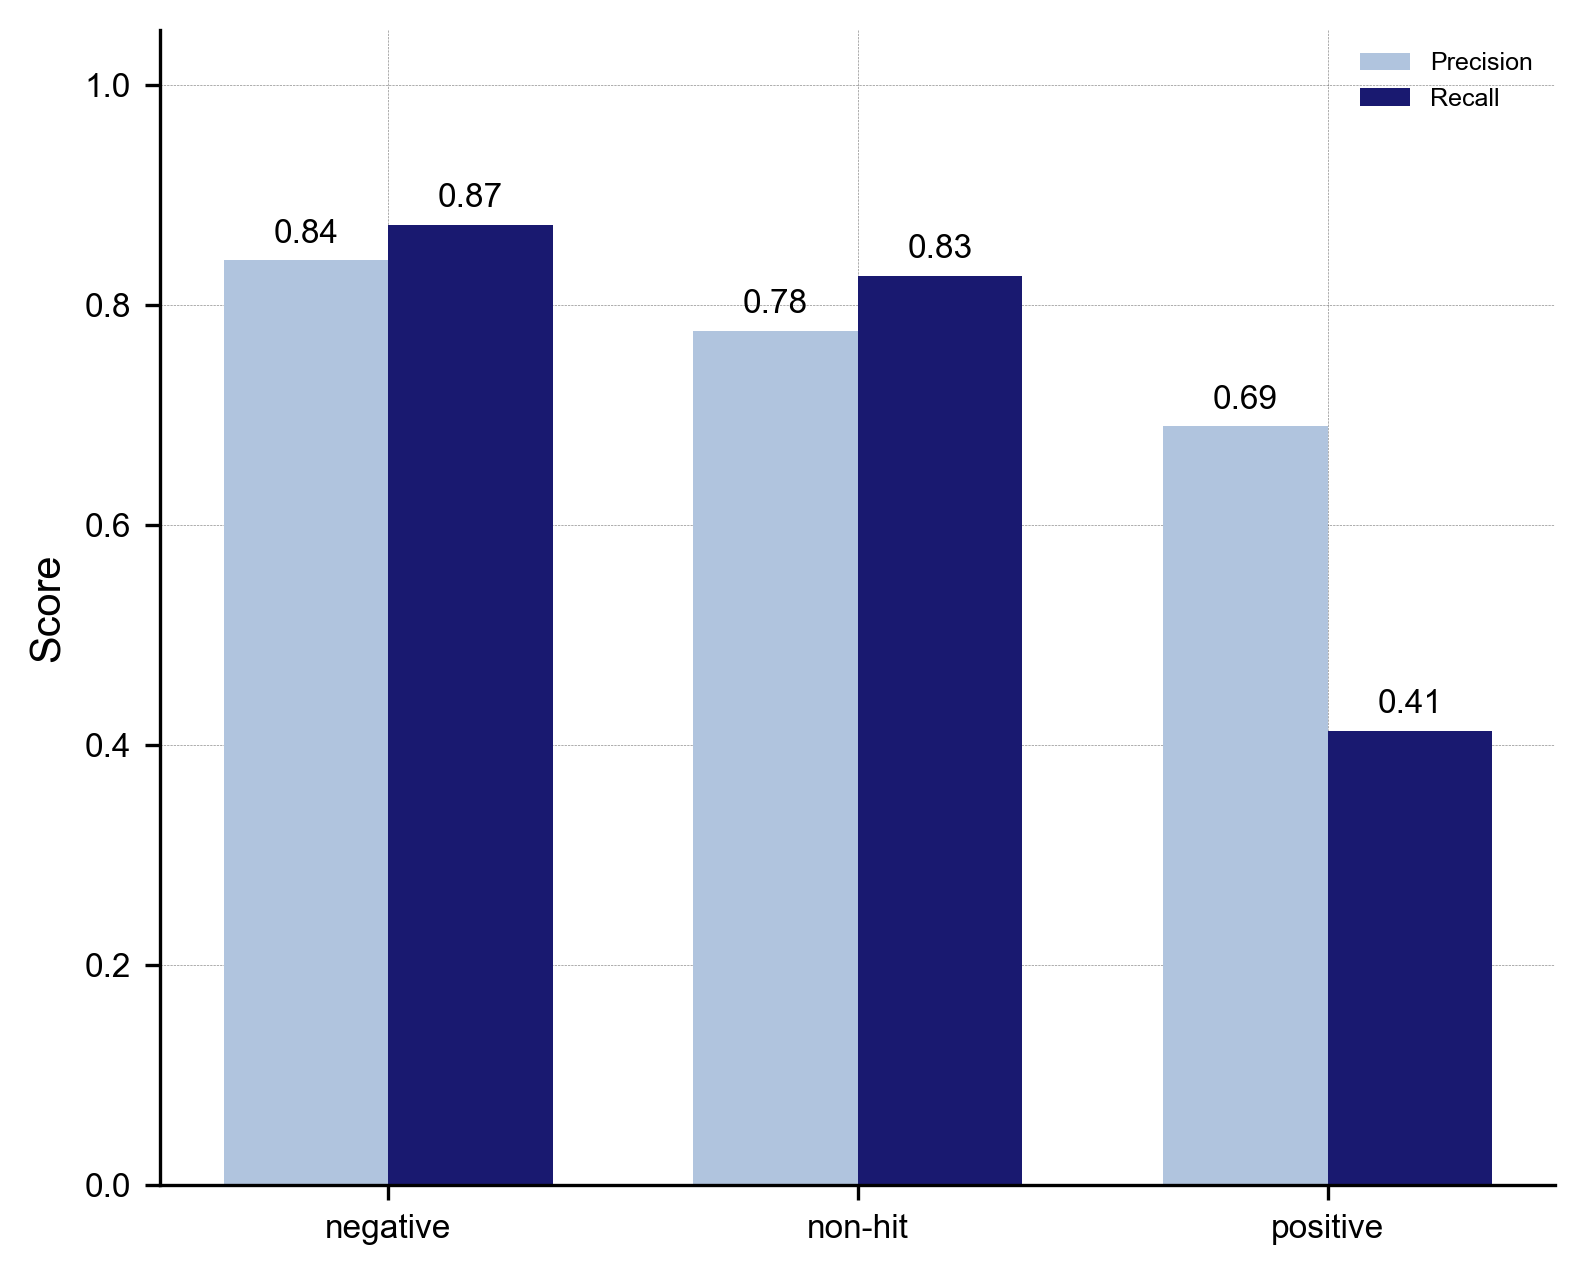

In [18]:
# Extract precision and recall per class from avg_report
class_names = ["negative", "non-hit", "positive"]

precision_means = [avg_report[c]["precision"] for c in class_names]
recall_means    = [avg_report[c]["recall"] for c in class_names]

x = np.arange(len(class_names))  # positions
width = 0.35  # bar width

plt.figure(figsize=(6,5))
bars1 = plt.bar(x - width/2, precision_means, width, label="Precision", color="lightsteelblue")
bars2 = plt.bar(x + width/2, recall_means, width, label="Recall", color="midnightblue")

# Add numbers on top of bars
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f"{height:.2f}", ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.01, 
             f"{height:.2f}", ha='center', va='bottom', fontsize=8)

# Customize fonts
plt.xticks(x, class_names, fontsize=8)
plt.yticks(fontsize=8)
plt.ylabel("Score", fontsize=10)
#plt.title("Precision and Recall per Class (5-fold CV average)", fontsize=16)
plt.legend(loc="upper right", fontsize=6)

plt.ylim(0, 1.05)  # leave space for labels
plt.show()

## Run with k downsamples

In [22]:
def train_test_once(df, model, meta_cols, le, cv, stratified_downsampling, random_state_for_downsampling):

    #Perform stratified downsampling
    df_balanced = stratified_downsampling(df, random_state=random_state_for_downsampling)

    #Separate train and test sets
    X = df_balanced.drop(columns=meta_cols + ["Hit_class_encoded"])
    y = df_balanced["Hit_class_encoded"]

    class_names = list(le.classes_)
    n_classes = len(class_names)

    fold_reports = []
    roc_auc_scores_weighted, roc_auc_scores_macro = [], []
    pr_auc_scores_weighted, pr_auc_scores_macro = [], []
    all_y_true, all_y_pred = [], []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        probs = model.predict_proba(X_val) 

        #ROC AUC
        roc_auc_scores_weighted.append(roc_auc_score(y_val, probs, multi_class="ovr", average='weighted'))
        roc_auc_scores_macro.append(roc_auc_score(y_val, probs, multi_class="ovr", average='macro'))

        #PR AUC
        pr_auc_scores_weighted.append(average_precision_score(y_val, probs, average='weighted'))
        pr_auc_scores_macro.append(average_precision_score(y_val, probs, average='macro'))

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

        report = classification_report(y_val, y_pred, target_names=le.classes_, output_dict=True)
        fold_reports.append(report)

    # Aggregate metrics - average across folds 
    metrics = {}
    metrics["accuracy"] = np.mean([r["accuracy"] for r in fold_reports])

    for avg_key in ["macro avg", "weighted avg"]:
        metrics[f"precision_{avg_key}"] = np.mean([r[avg_key]["precision"] for r in fold_reports])
        metrics[f"recall_{avg_key}"]    = np.mean([r[avg_key]["recall"] for r in fold_reports])
        metrics[f"f1_{avg_key}"]        = np.mean([r[avg_key]["f1-score"] for r in fold_reports])

    for cname in class_names:
        metrics[f"precision_{cname}"] = np.mean([r[cname]["precision"] for r in fold_reports])
        metrics[f"recall_{cname}"]    = np.mean([r[cname]["recall"]    for r in fold_reports])
        metrics[f"f1_{cname}"]        = np.mean([r[cname]["f1-score"]  for r in fold_reports])

    metrics["roc_auc_weighted"] = np.mean(roc_auc_scores_weighted)
    metrics["roc_auc_macro"]    = np.mean(roc_auc_scores_macro)
    metrics["pr_auc_weighted"]  = np.mean(pr_auc_scores_weighted)
    metrics["pr_auc_macro"]     = np.mean(pr_auc_scores_macro)

    #print(f'all-true:{all_y_true}')
    #print(f'all-pred:{all_y_pred}')

    cm = confusion_matrix(all_y_true, all_y_pred, labels=np.arange(len(le.classes_)))
    return metrics, cm

In [23]:
# Run multiple times to get average performance across different downsamplings
n_runs = 10
all_metrics = []
all_cms = []

xgb_classifier_optimized = XGBClassifier(
    subsample=0.85,
    reg_lambda=1.3,
    reg_alpha=1,
    n_estimators=300,
    min_child_weight=3,
    max_depth=9,
    learning_rate=0.2,
    colsample_bytree=1.0,
    objective="multi:softprob",   
    num_class=len(le.classes_),   
    random_state=1,
    n_jobs=-1                    
)

for i in range(n_runs):
    print(f"\n--- Run {i+1}/{n_runs} ---")
    metrics, cm = train_test_once(
        df=annotated_control_vs_plasmid_EG,
        model=xgb_classifier_optimized,
        meta_cols=meta_cols,
        le=le,
        cv=skf,
        stratified_downsampling=stratified_downsampling,
        random_state_for_downsampling=i  # Different seed for each run
    )
    all_metrics.append(metrics)
    all_cms.append(cm)
    print("Metrics:", metrics)
    print("Confusion Matrix:\n", cm)

# Aggregate metrics across runs
# Convert metrics into DataFrame for mean/std
metrics_df = pd.DataFrame(all_metrics)
metrics_mean = metrics_df.mean()
metrics_std = metrics_df.std()

cm_mean = np.mean(np.array(all_cms, dtype=float), axis=0)
cm_std = np.std(np.array(all_cms, dtype=float), axis=0)

print("=== Mean metrics ===")
print(metrics_mean)
print("\n=== Std metrics ===")
print(metrics_std)

print("\n=== Mean confusion matrix ===")
print(cm_mean)
print("\n=== Std confusion matrix ===")
print(cm_std)


--- Run 1/10 ---
Metrics: {'accuracy': np.float64(0.7875418769821771), 'precision_macro avg': np.float64(0.7436117340289621), 'recall_macro avg': np.float64(0.682184214483956), 'f1_macro avg': np.float64(0.6992839595834281), 'precision_weighted avg': np.float64(0.7813418696257576), 'recall_weighted avg': np.float64(0.7875418769821771), 'f1_weighted avg': np.float64(0.7790485911011313), 'precision_negative': np.float64(0.8444159306876415), 'recall_negative': np.float64(0.8592592592592592), 'f1_negative': np.float64(0.8513936763632927), 'precision_non-hit': np.float64(0.7580912290712021), 'recall_non-hit': np.float64(0.8271604938271604), 'f1_non-hit': np.float64(0.7909753681111656), 'precision_positive': np.float64(0.6283280423280424), 'recall_positive': np.float64(0.3601328903654485), 'f1_positive': np.float64(0.45548283427582587), 'roc_auc_weighted': np.float64(0.8872505865183742), 'roc_auc_macro': np.float64(0.8648133184960759), 'pr_auc_weighted': np.float64(0.8126242953689852), 'pr_

In [24]:
def summarize_results(metrics_list, cms, class_names):
    """
    Summarize metrics (global + class-wise) and confusion matrices across runs.

    Parameters
    ----------
    metrics_list : list of dict
        Each element is the metrics dict returned from train_test_once.
    cms : list of np.ndarray
        Confusion matrices (one per run).
    class_names : list
        Names of classes for the confusion matrix.
    """

    # === Metrics summary ===
    metrics_keys = metrics_list[0].keys()
    summary = {}
    for key in metrics_keys:
        values = np.array([m[key] for m in metrics_list])
        summary[key] = (np.mean(values), np.std(values))

    print("\n=== Metrics Summary (mean ± std) ===")

    # Global averages
    for k in ["accuracy", "roc_auc_weighted", "roc_auc_macro",
              "pr_auc_weighted", "pr_auc_macro"]:
        mean, std = summary[k]
        print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Macro/weighted averages
    for k in ["precision_macro avg", "recall_macro avg", "f1_macro avg",
              "precision_weighted avg", "recall_weighted avg", "f1_weighted avg"]:
        if k in summary:
            mean, std = summary[k]
            print(f"{k:20s}: {mean:.3f} ± {std:.3f}")

    # Class-wise metrics
    print("\n=== Class-wise Metrics (mean ± std) ===")
    for cname in class_names:
        for metric in ["precision", "recall", "f1"]:
            key = f"{metric}_{cname}"
            if key in summary:
                mean, std = summary[key]
                print(f"{cname:10s} {metric:10s}: {mean:.3f} ± {std:.3f}")

    # === Confusion Matrix summary ===
    cm_array = np.stack(cms)  # shape (n_runs, n_classes, n_classes)
    cm_mean = np.mean(cm_array, axis=0)
    cm_std = np.std(cm_array, axis=0)

    # Combined annotated version
    combined = np.empty(cm_mean.shape, dtype=object)
    for i in range(cm_mean.shape[0]):
        for j in range(cm_mean.shape[1]):
            mean_val = int(round(cm_mean[i, j]))   # integer
            std_val = int(cm_std[i, j])       # 1 decimal
            combined[i, j] = f"{mean_val}±{std_val}"

    #for i in range(cm_mean.shape[0]):
    #    for j in range(cm_mean.shape[1]):
    #        combined[i, j] = f"{cm_mean[i,j]:.1f}±{cm_std[i,j]:.1f}"

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_mean, annot=combined, fmt="", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    #plt.title("Confusion Matrix (mean ± std)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return summary, cm_mean, cm_std


=== Metrics Summary (mean ± std) ===
accuracy            : 0.788 ± 0.006
roc_auc_weighted    : 0.889 ± 0.005
roc_auc_macro       : 0.867 ± 0.005
pr_auc_weighted     : 0.816 ± 0.008
pr_auc_macro        : 0.735 ± 0.010
precision_macro avg : 0.746 ± 0.012
recall_macro avg    : 0.686 ± 0.009
f1_macro avg        : 0.703 ± 0.010
precision_weighted avg: 0.782 ± 0.007
recall_weighted avg : 0.788 ± 0.006
f1_weighted avg     : 0.780 ± 0.007

=== Class-wise Metrics (mean ± std) ===
negative   precision : 0.841 ± 0.006
negative   recall    : 0.866 ± 0.009
negative   f1        : 0.853 ± 0.006
non-hit    precision : 0.762 ± 0.008
non-hit    recall    : 0.818 ± 0.010
non-hit    f1        : 0.789 ± 0.007
positive   precision : 0.634 ± 0.032
positive   recall    : 0.375 ± 0.019
positive   f1        : 0.468 ± 0.021


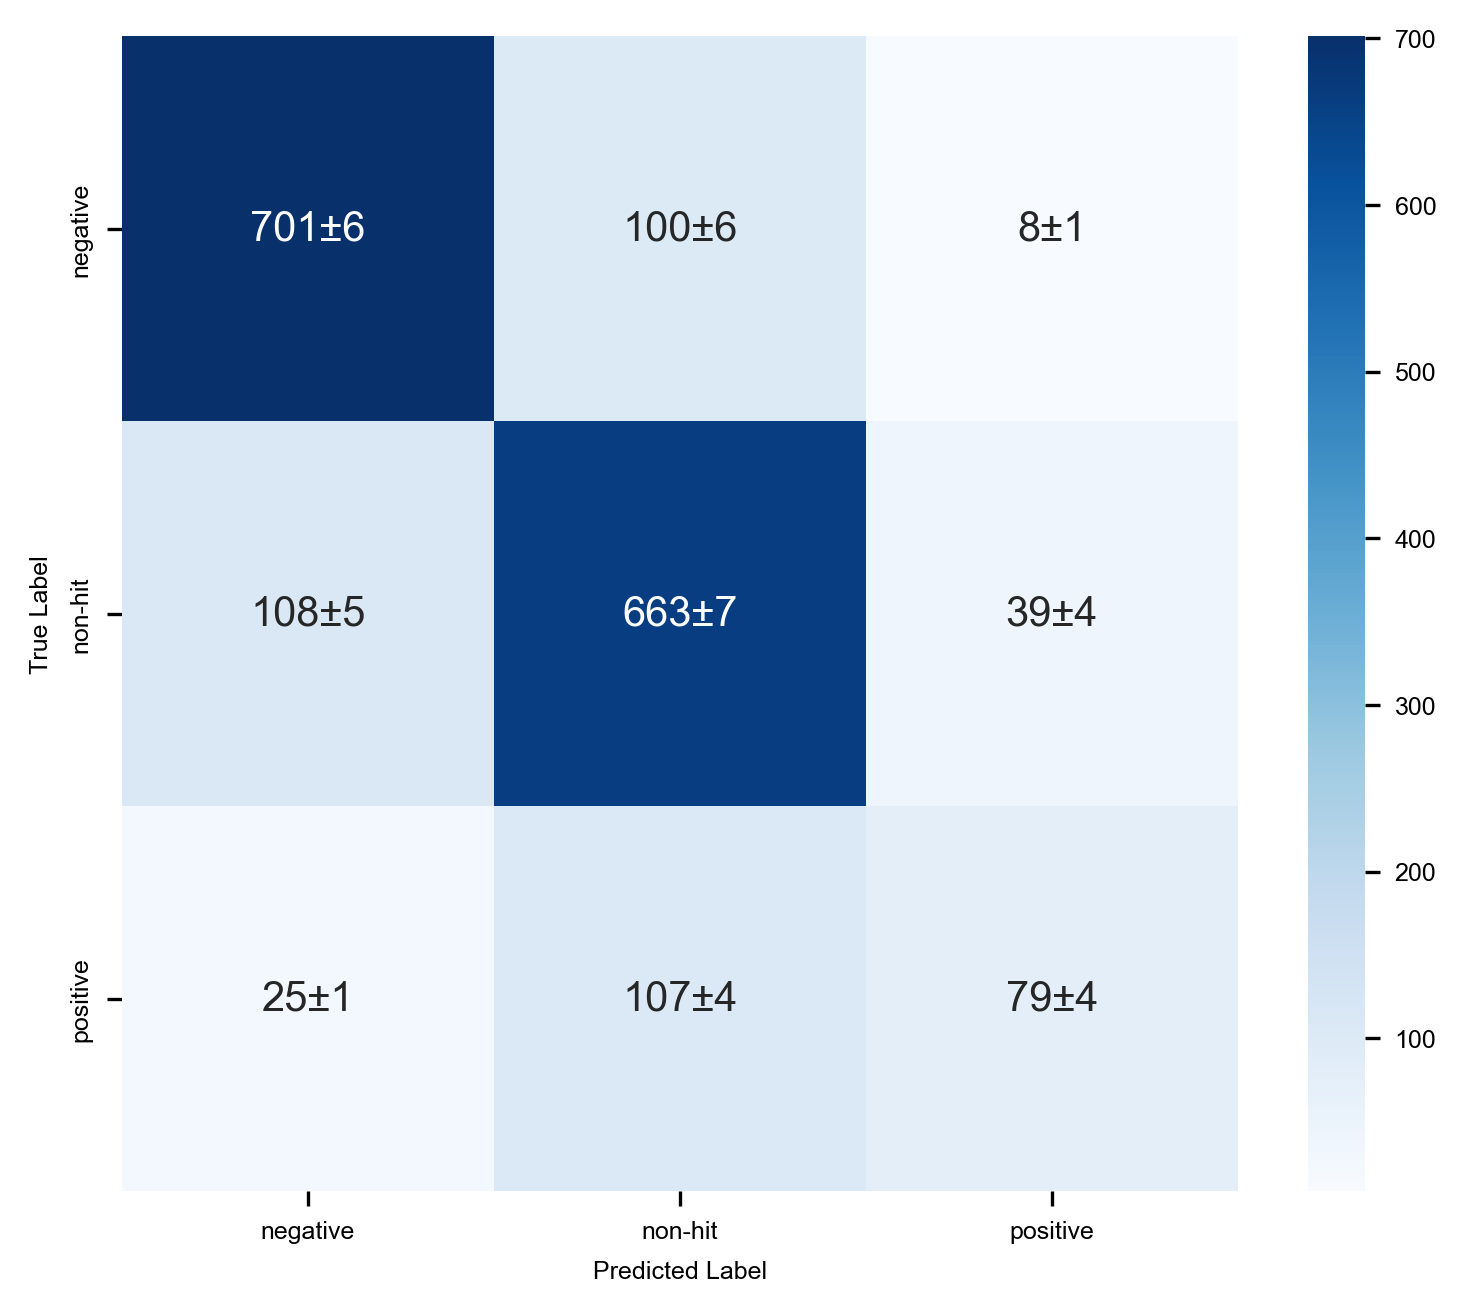

In [25]:
metrics_summary, cm_mean, cm_std = summarize_results(all_metrics, all_cms,
                                                     class_names=le.classes_)

## Hyperparameter Tunning

### Random Search

In [49]:
params = {
    "n_estimators": [50, 100, 200, 300, 500, 700, 1000, 1500, 2000],  # number of boosting rounds
    "max_depth": [3, 6, 9, 12],                         
    "learning_rate": [0.01, 0.1, 0.2],              
    "subsample": [0.7, 0.85, 1.0],                  # defines the fraction of training instances to be used for each tree
    "colsample_bytree": [0.7, 0.85, 1.0],           # feature sampling
    "min_child_weight": [1, 3, 5],                  # min sum of instance weight in child
    "reg_alpha": [0, 0.01, 0.1, 1, 10, 50],         # L1 regularization
    "reg_lambda": [0.5, 0.7, 1, 1.3],               # L2 regularization
}

xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=200,               
    scoring="f1_macro",    
    cv=cv,
    verbose=2,
    random_state=1,
    n_jobs=-1
)

start = time.time()
random_search.fit(X, y)
end = time.time()

#Best parameters and score from tuning 
print("Best parameters: ", random_search.best_params_)
print("Best score (f1_macro): ", random_search.best_score_)
print(f"\nTotal tuning time: {end - start:.2f} seconds")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.3s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.4s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=9, min_child_weight=5, n_estimators=50, reg_alpha=0, reg_lambda=1, subsample=1.0; total time=   1.5s
[CV] END colsample_bytree=0.7, learning_rate=0.2, max_depth=12, min_child_weight=1, n_estimators=50, reg_alpha=10, reg_lambda=

### Bayes Optimization

In [103]:
params_bayes = {
    'n_estimators': Integer(50, 2000),
    'max_depth': Integer(3, 9),
    'learning_rate': Real(0.01, 0.2, prior='log-uniform'),  
    'subsample': Real(0.7, 1.0),
    'colsample_bytree': Real(0.7, 1.0),
    'min_child_weight': Integer(1, 10),
    'reg_alpha': Real(0.0001, 50, prior='log-uniform'),  # L1 
    'reg_lambda': Real(0.0001, 2, prior='log-uniform'),    # L2 
}

xgb = XGBClassifier(
    objective="multi:softprob", 
    num_class=len(le.classes_), 
    random_state=1
)

# Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

bayes_search = BayesSearchCV(
    estimator=xgb,
    search_spaces=params_bayes,
    n_iter=100,               
    scoring="f1_weighted",    
    cv=cv,
    verbose=2,
    random_state=1,
    n_jobs=-1
)

start = time.time()
bayes_search.fit(X, y)
end = time.time()

#Best parameters and score from tuning
print("Best parameters: ", bayes_search.best_params_)
print("Best score (f1_macro): ", bayes_search.best_score_)
print(f"\nTotal tuning time: {end - start:.2f} seconds")


Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   4.7s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   4.8s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146, subsample=0.7767084453482135; total time=   4.8s
[CV] END colsample_bytree=0.9107934977333076, learning_rate=0.012028480054085435, max_depth=5, min_child_weight=2, n_estimators=1012, reg_alpha=11.640167211727219, reg_lambda=0.00017846585664349146